In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data3,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix1
CUDA_LAUNCH_BLOCKING=2

def ana_S(x, center,R, r, S0):
    x1=x[:,0]
    x2=x[:,1]
    x3=x[:,2]
    cx, cy, cz = center[0,0],center[0,1],center[0,2]
    
    # 计算每个点相对于偏移中心是否在环形内部的条件a
    
    x_rel, y_rel, z_rel = x1 - cx, x2 - cy, x3 - cz
    condition = (np.sqrt(x_rel**2 + y_rel**2) - R)**2 + z_rel**2 <= r**2
    
    # 使用 np.where 根据条件返回 S0 或 0
    return np.where(condition, S0, 0.0)

cuda:2


In [2]:
import copy
Nx,Ny,Nz=1,1,1
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
R_true = 0.25            # 主半径 R
r_true = 0.15            # 次半径 r
S0= 1.0  
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=-0.5,0.5,-0.5,0.5,-0.5,0.5
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.75,0.75,-0.75,0.75,-0.75,0.75 #边界gamma处
num_batches_gauss=1
b_n=10
points_b=mea_3D.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) #在边界Γ处收集数据
center_true=np.array([[0.0,0.0,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=2
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1

In [3]:
F_diri_5=np.load("./noise=5%/F_diri_5%.npy")


In [8]:
M=5200
af="Tanh"   #先用tanh
R_m=20
models0 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=tau_x_min, x_min=tau_x_max, y_max=tau_y_max, y_min=tau_y_min,z_min=tau_z_min,z_max=tau_z_max, r_min=[], r_max=[],R_min=[],R_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,Shape=[],device=device).to(device)

In [5]:
models0=torch.load("./noise=5%/model_tanh_4*10**-4.pth", map_location=device)

Plotting 64 cells. Levels: 0 to 0


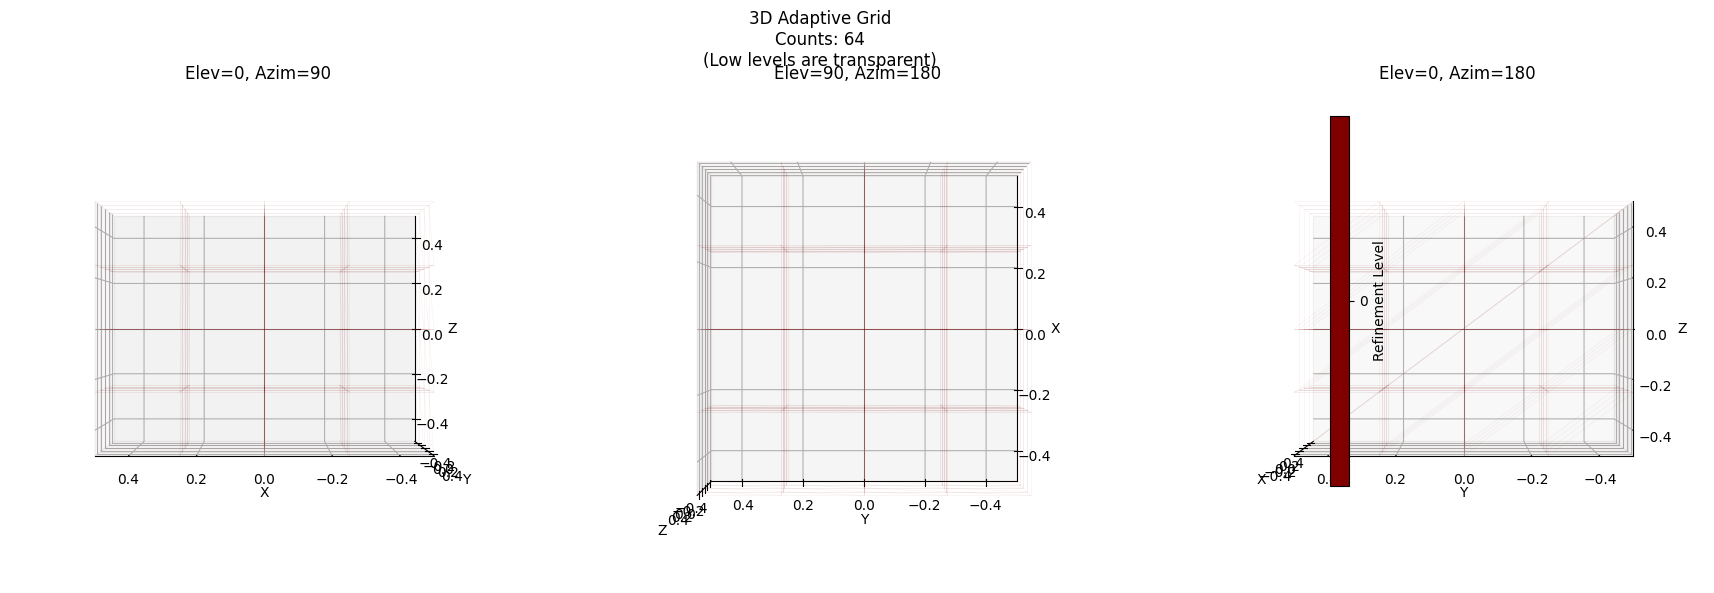

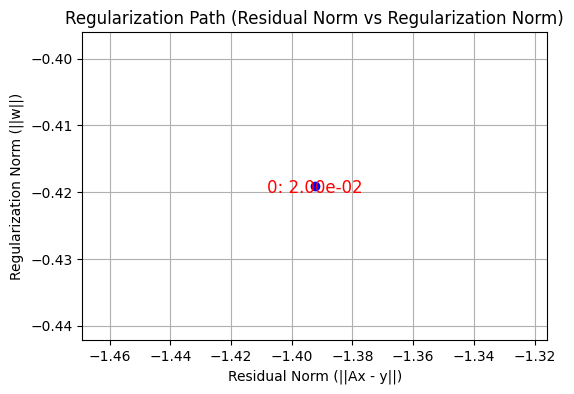

第 0 次迭代的train误差：
S_l_inf= 1.9058529428023316 S_L_2= 0.14774740044079246 S_l_2= 0.40322525478492083
第 0 次迭代的泛化误差：


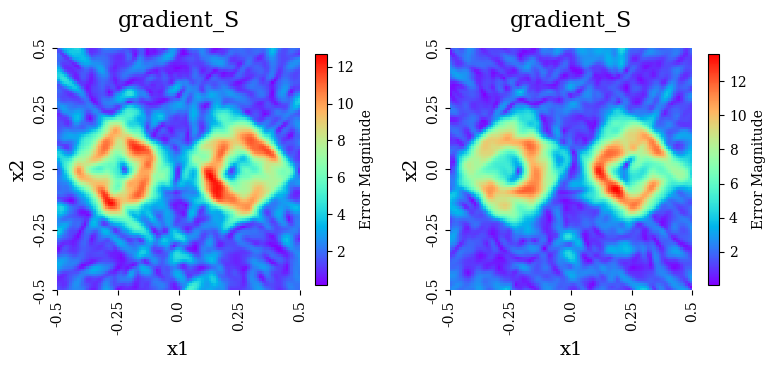

S_l_inf= 2.3672735970001644 S_L_2= 0.14165363608423379 S_l_2= 0.4328911670110538


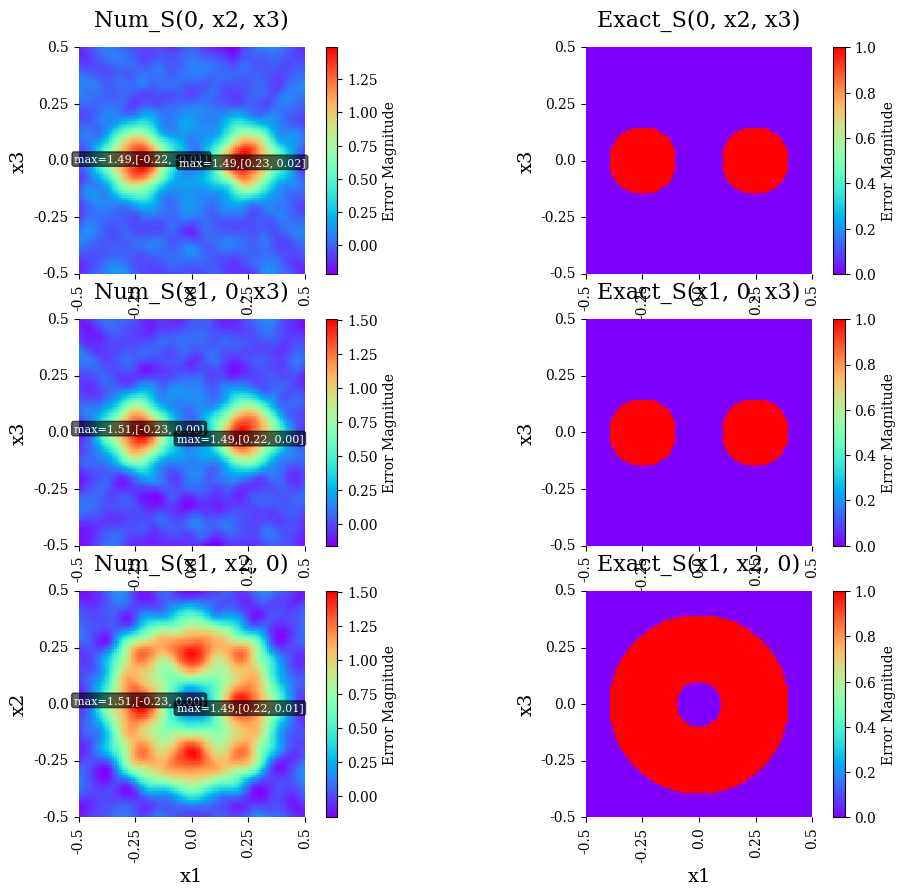

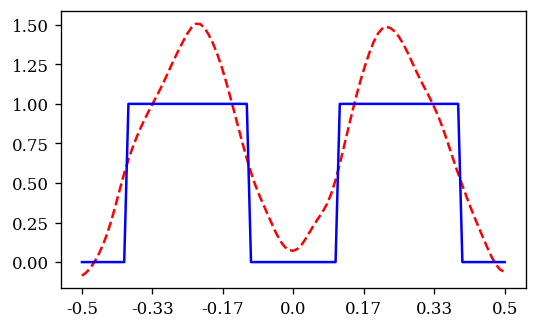

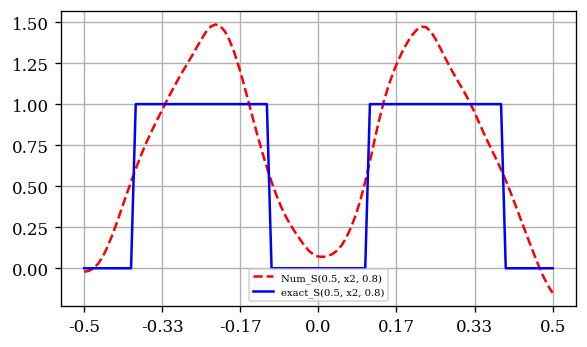

S_l_inf= 1.9058529428023316 S_L_2= 0.14774740044079246 S_l_2= 0.40322525478492083
S_l_inf= 2.1477366810159473 S_L_2= 0.14825995483998902 S_l_2= 0.43798893345078693
当前总网格数目: 512
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 512 cells. Levels: 1 to 1


/mnt/store/hxw-y23/MA-RFM-GIT/3D_donut/./main_code/main_fix1.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


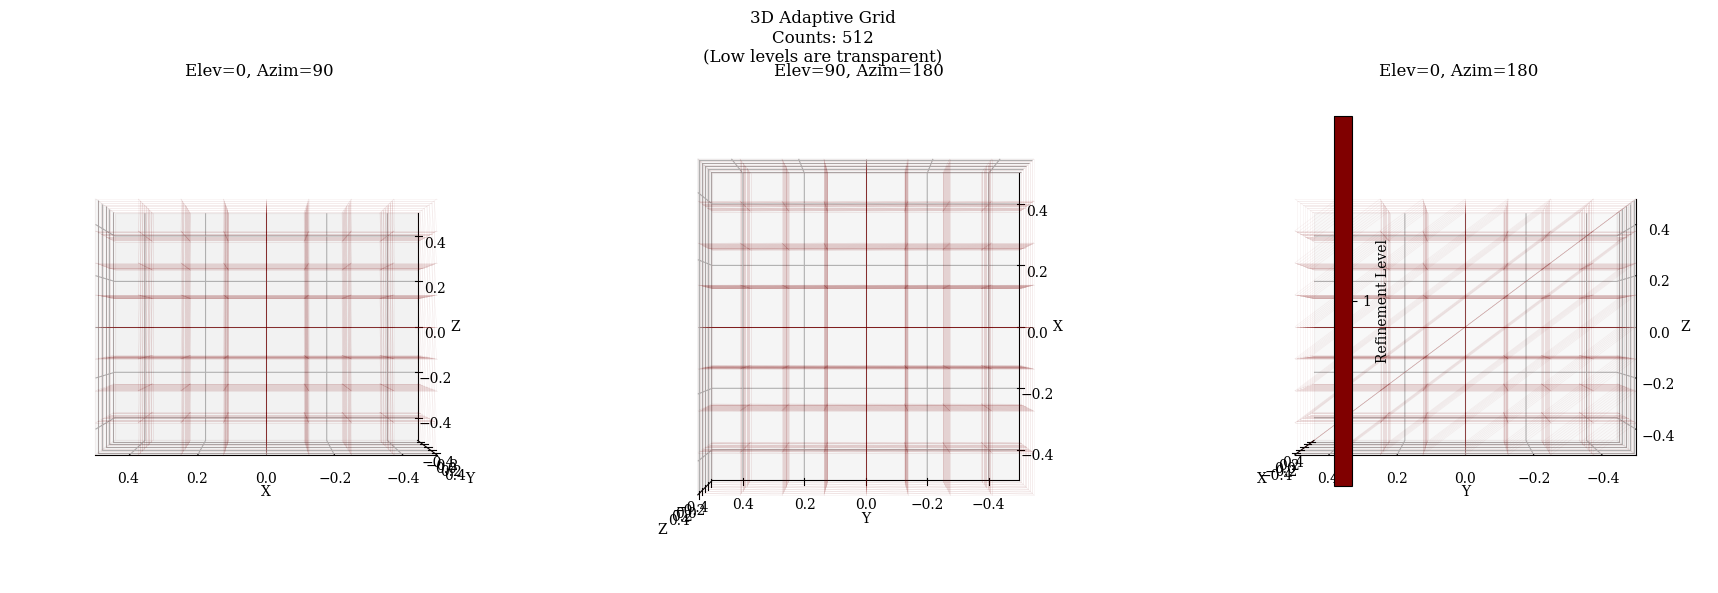

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


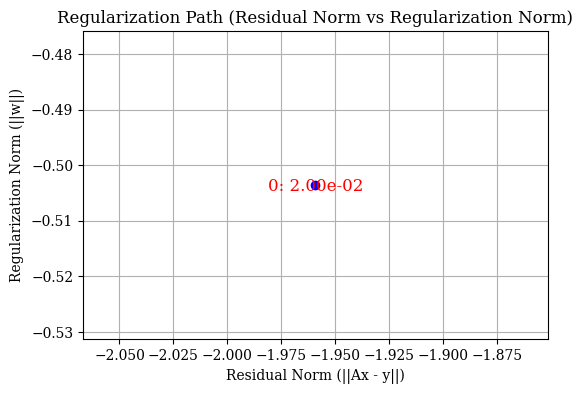

第 1 次迭代的train误差：
S_l_inf= 1.7794323312890348 S_L_2= 0.11809923607422801 S_l_2= 0.3488882652455262
第 1 次迭代的泛化误差：


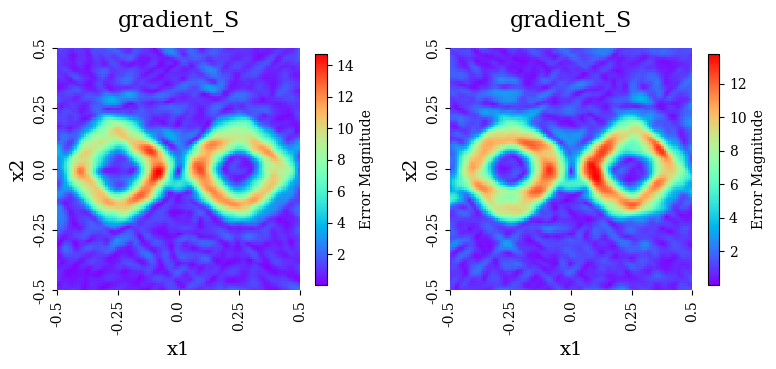

S_l_inf= 2.0108089352759406 S_L_2= 0.11468605303217191 S_l_2= 0.3504786796116293


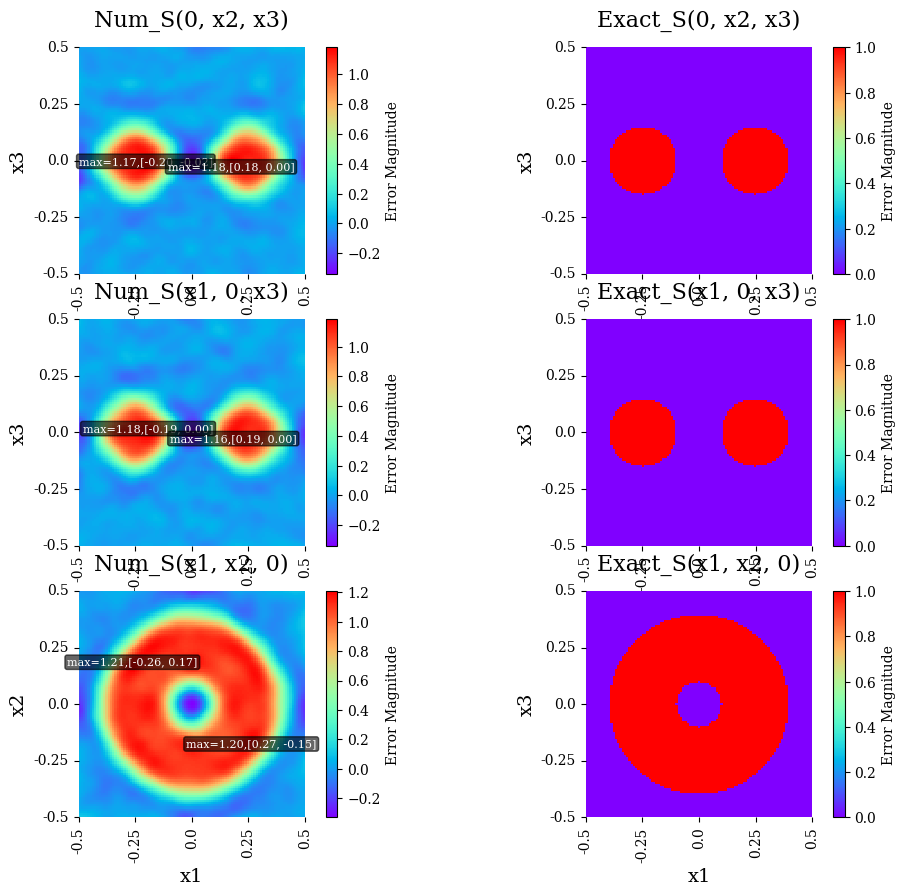

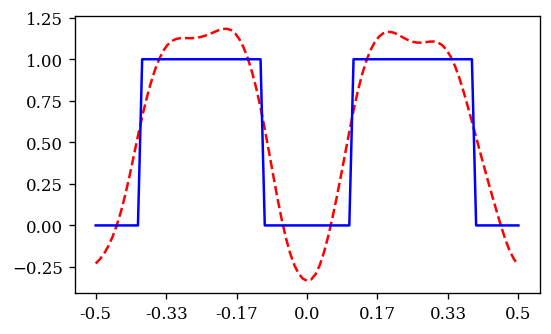

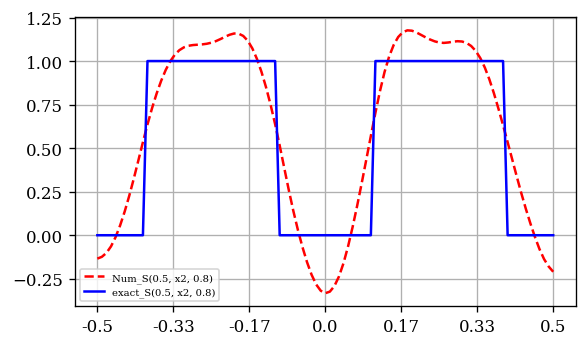

S_l_inf= 1.7794323312890348 S_L_2= 0.11809923607422801 S_l_2= 0.3488882652455262
S_l_inf= 1.9860437238455466 S_L_2= 0.11557354152081666 S_l_2= 0.34672062456245
当前总网格数目: 1408
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 1408 cells. Levels: 1 to 2


/mnt/store/hxw-y23/MA-RFM-GIT/3D_donut/./main_code/main_fix1.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


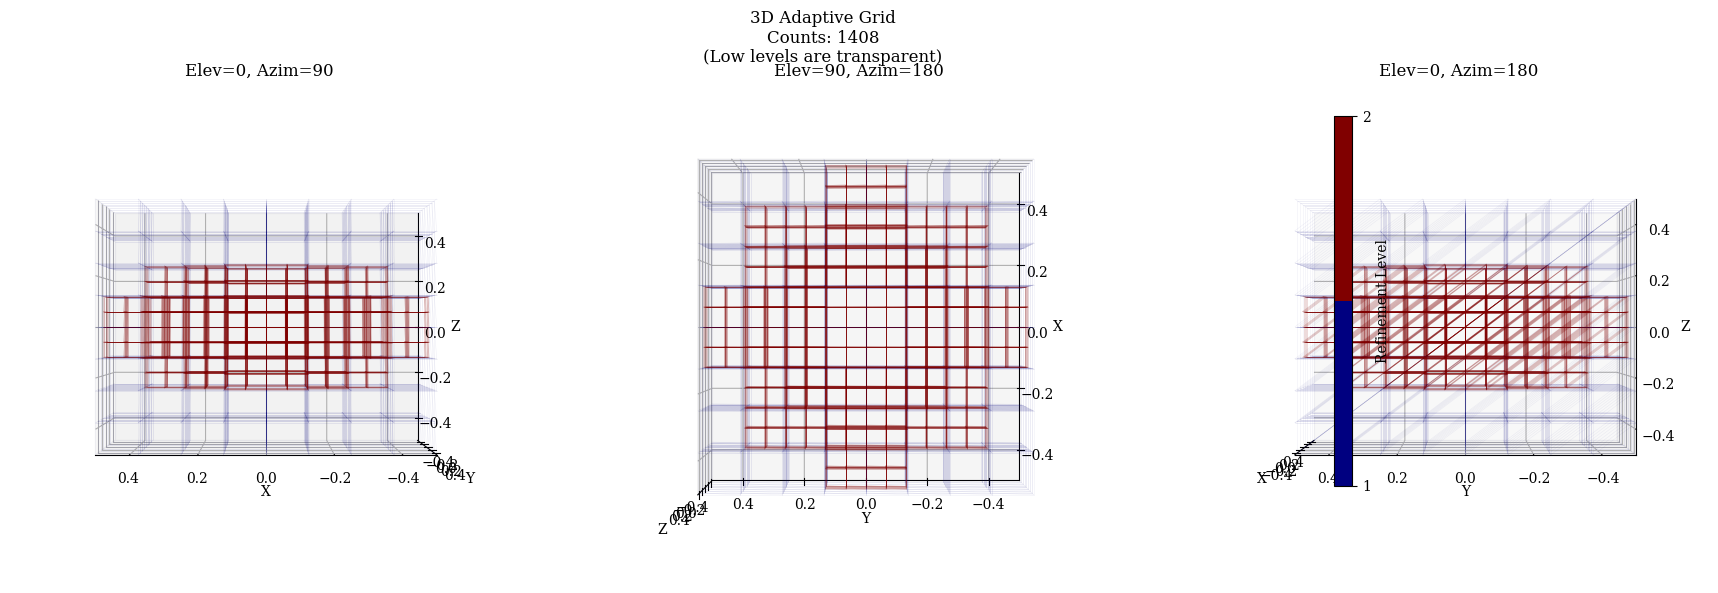

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


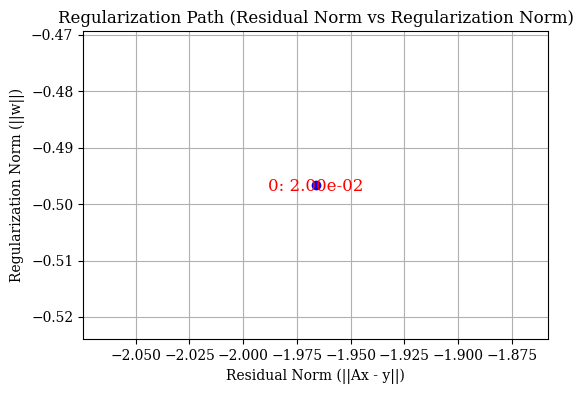

第 2 次迭代的train误差：
S_l_inf= 1.1664020250473952 S_L_2= 0.1880956357572323 S_l_2= 0.3314906014531792
第 2 次迭代的泛化误差：


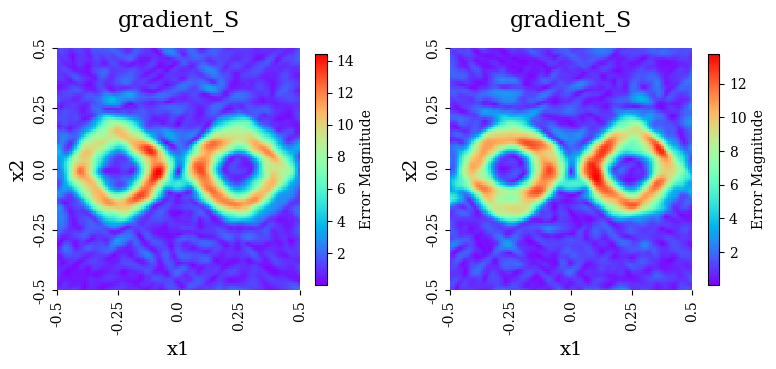

S_l_inf= 2.0151088419569523 S_L_2= 0.11403703471468483 S_l_2= 0.34849529037690846


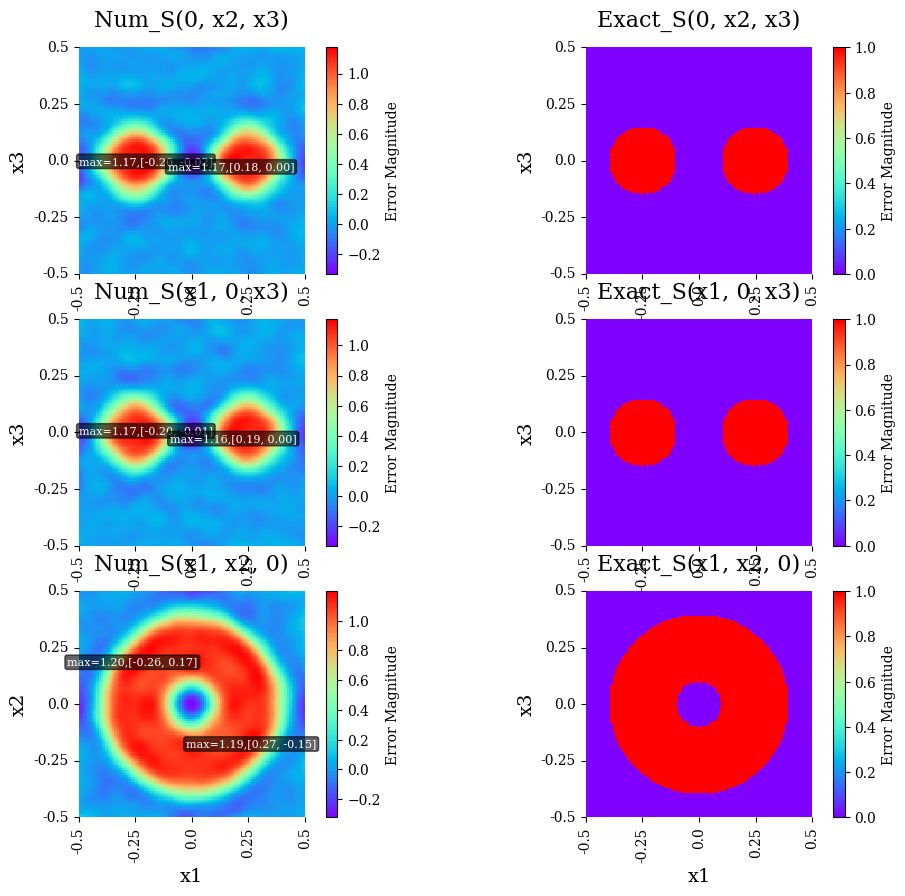

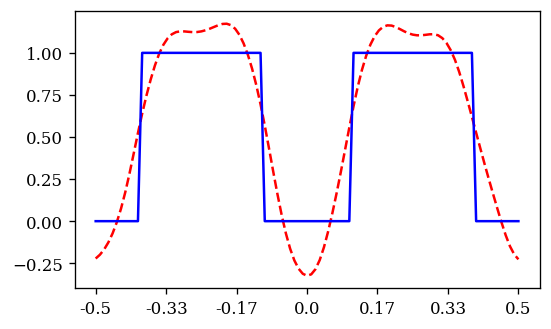

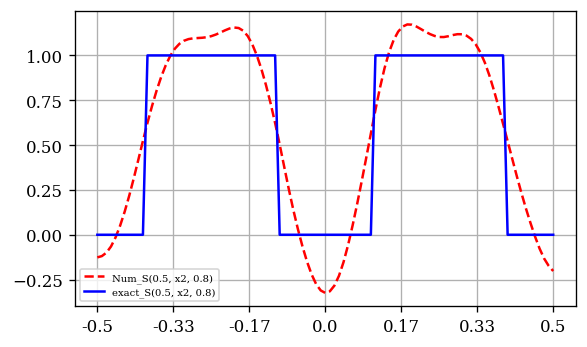

S_l_inf= 1.1664020250473952 S_L_2= 0.1880956357572323 S_l_2= 0.3314906014531792
S_l_inf= 1.167592352592607 S_L_2= 0.18847501659003202 S_l_2= 0.3331404738796102
当前总网格数目: 1408
Visualization failed: name 'MeshVisualizer' is not defined


In [9]:
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
ratio1=[0.5,0.5,0.5]
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
delta=10**(-3)

lamb_regu=2*np.logspace(-2,-1,1)
Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/100000] * 5
refine_threshold_noise=[1/300] * 5
condition="Dirichlet"
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_l2,S_basis_store=main_fix1.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F_diri_5,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,R_true,r_true,S0,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,condition,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)